Random_state:  88
Random_state:  54
              precision    recall  f1-score   support

     Atruman       0.83      0.83      0.83         6
         Not       0.92      0.92      0.92        12

    accuracy                           0.89        18
   macro avg       0.88      0.88      0.88        18
weighted avg       0.89      0.89      0.89        18

Accuracy: 88.88888888888889 %


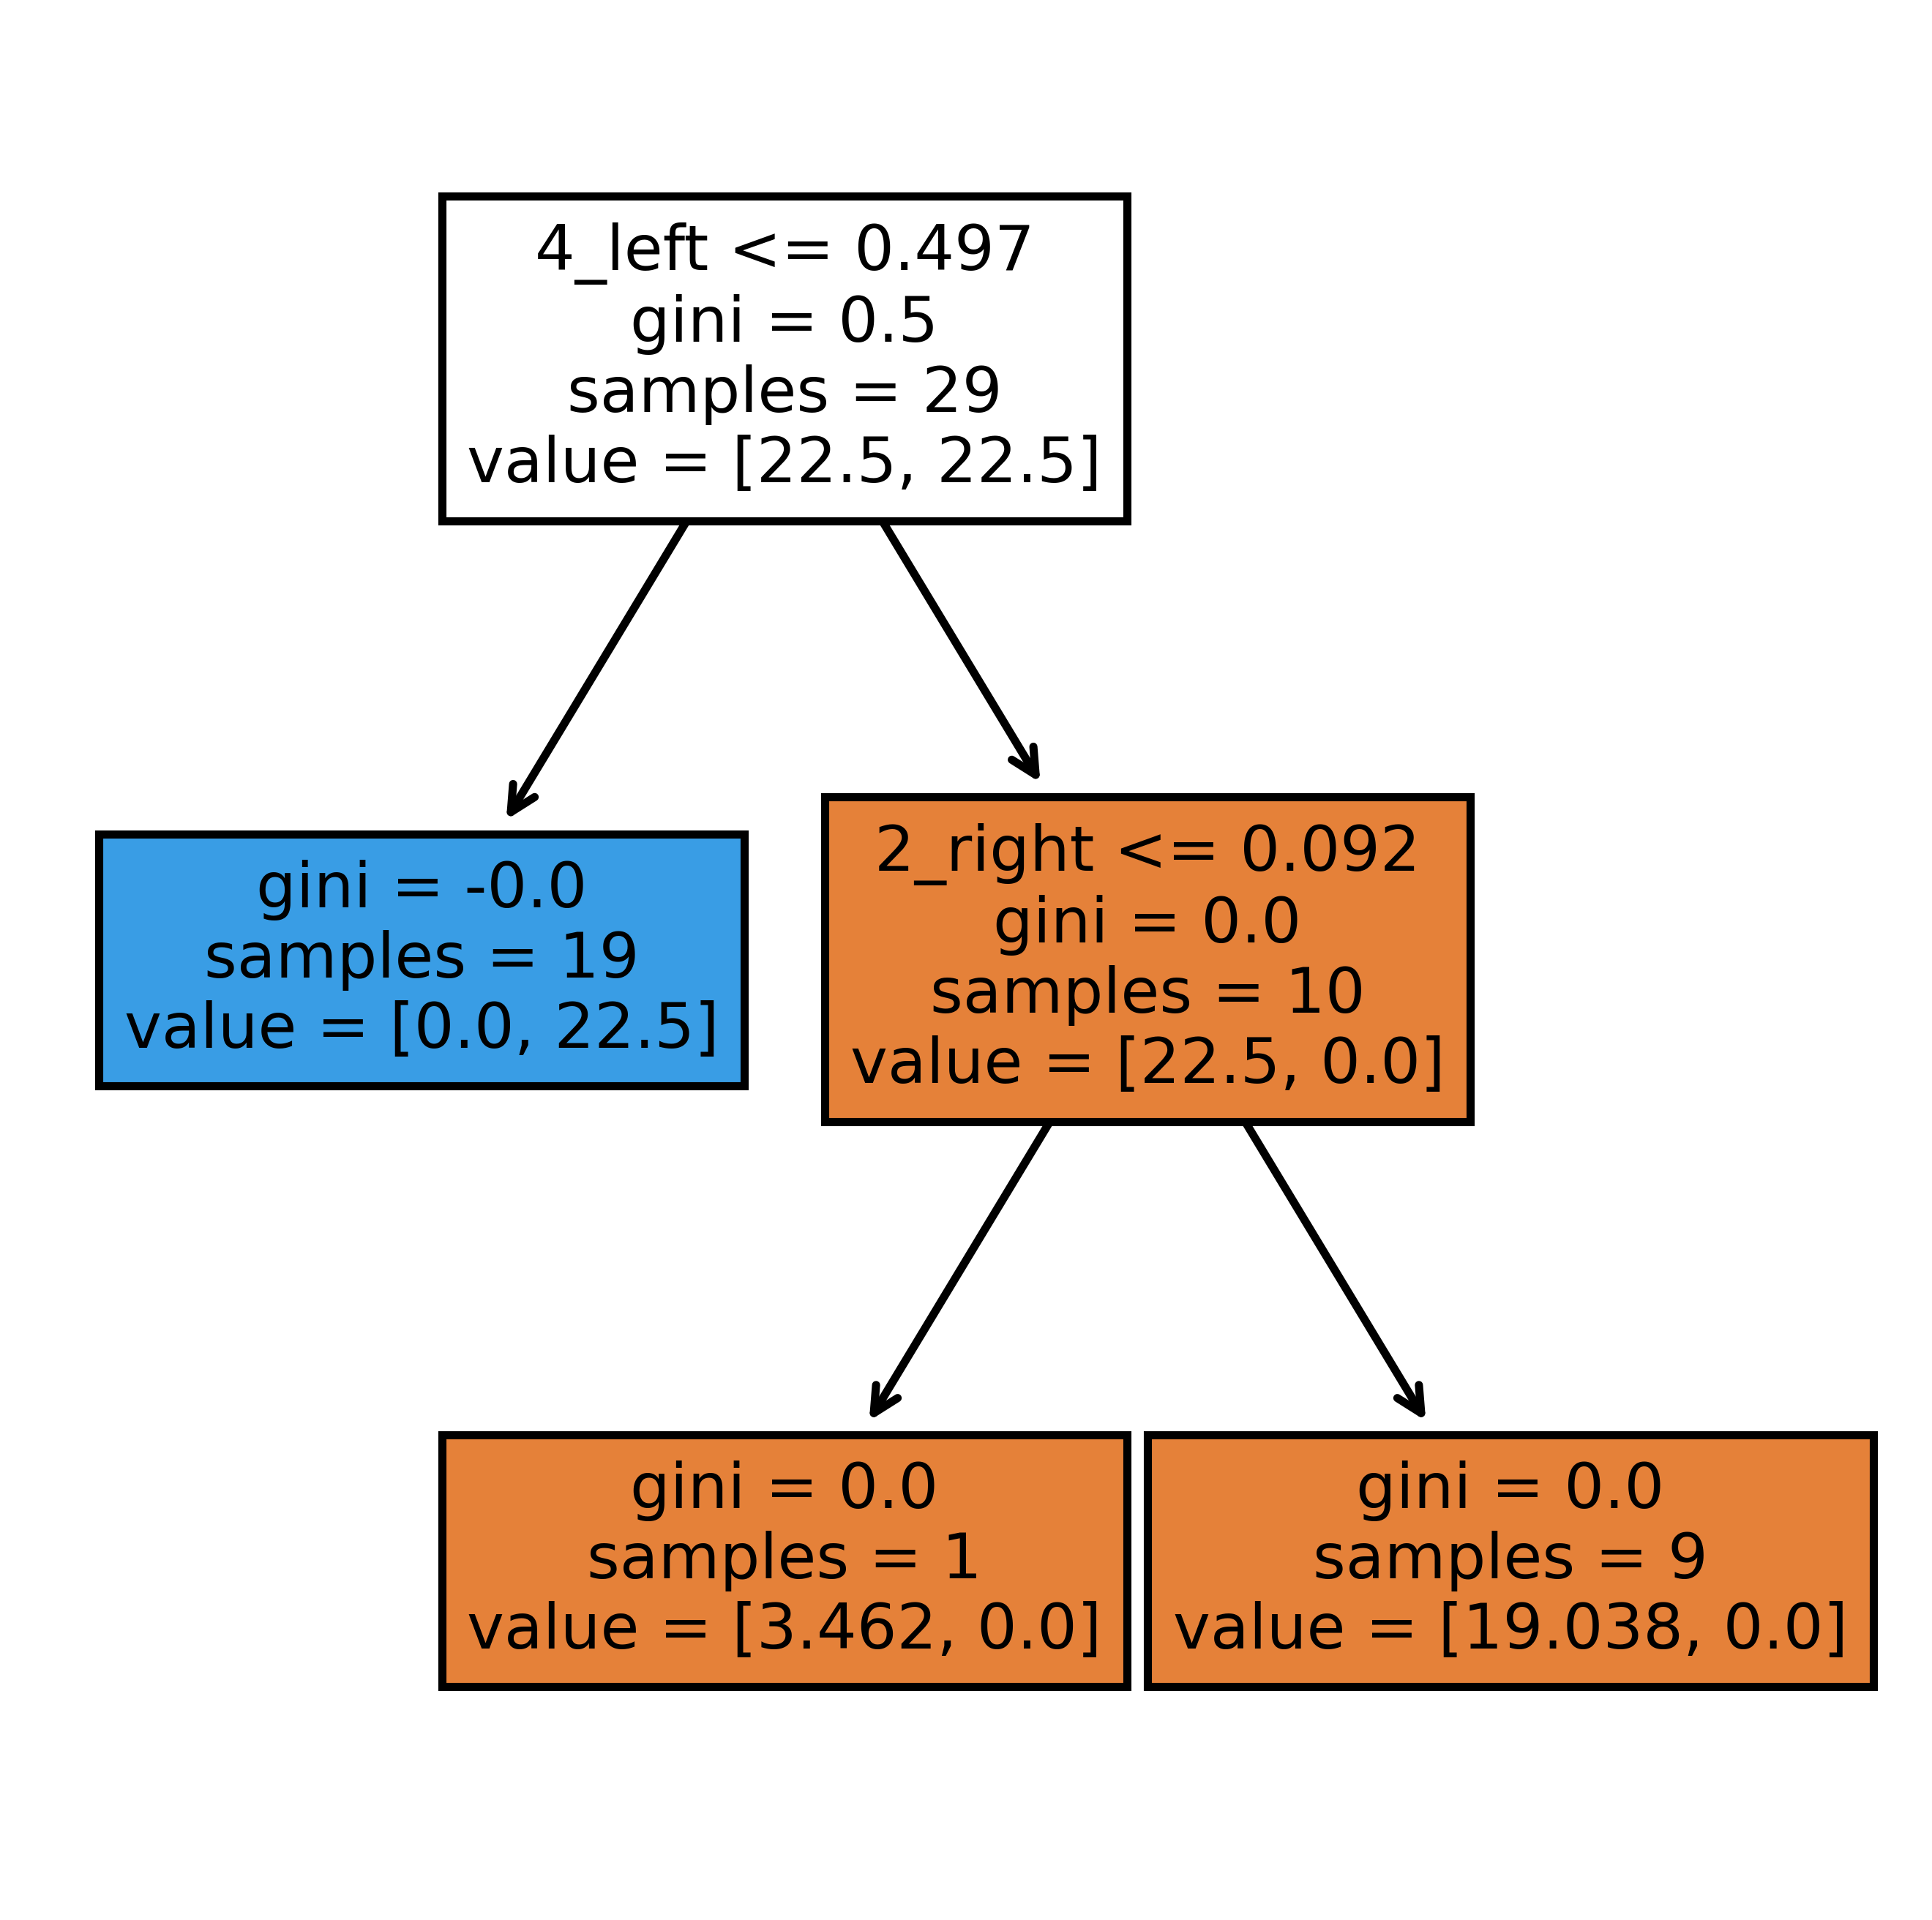

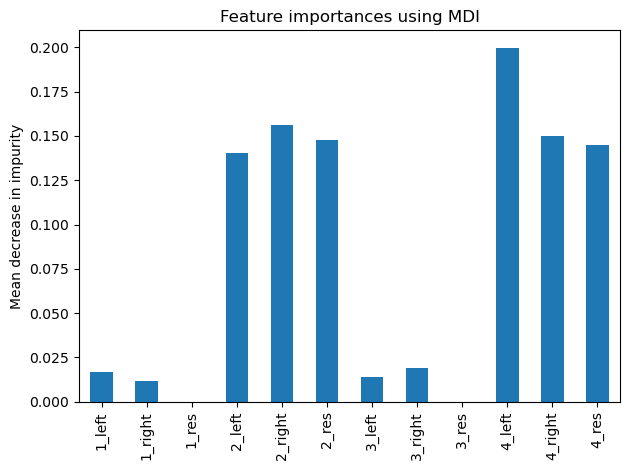

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
from xgboost import *
from dtreeviz import model
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier

fullinfo=True
fulltree=False

def class1_1():
    Treatment=pd.read_csv("../AD report/Atra pathway_1 train.csv")
    Treatment_test=pd.read_csv("../AD report/Atra pathway_1 test.csv")

    X_train=Treatment.iloc[:,1:]
    y_train=Treatment.iloc[:,0]

    X_test=Treatment_test.iloc[:,1:]
    y_test=Treatment_test.iloc[:,0]

    clf=XGBClassifier(tree_method="hist",
                      normalize_type="forest",
                      booster="dart",
                      subsample=0.8, 
                      eta=0.4,
                      colsample_bytree=0.6,
                      sample_type="weighted",
                      rate_drop=1,
                      skip_drop=0.6,
                      objective="reg:logistic",
                      random_state=67
    )
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test,iteration_range=(0, 100))
    y_pred = (y_pred > 0.5) 
        
    if fulltree==True:
        clf.fit(X_train, y_train)
        plt.figure(figsize=(400, 120))
        plot_tree(clf)
    accuracy = accuracy_score(y_test, y_pred)
    y_pred1 = clf.predict_proba(X_train,iteration_range=(0, 10))
    y_pred = clf.predict(X_train,iteration_range=(0, 10))
    y_pred3 = clf.predict_proba(X_test,iteration_range=(0, 10))
    y_pred2 = clf.predict(X_test,iteration_range=(0, 10)) 
    return y_pred1, y_pred,y_pred3, y_pred2


def class2_1():
    Treatment=pd.read_csv("../AD report/Atra pathway_2 train.csv")
    Treatment_test=pd.read_csv("../AD report/Atra pathway_2 test.csv")

    X_train=Treatment.iloc[:,1:]
    y_train=Treatment.iloc[:,0]

    X_test=Treatment_test.iloc[:,1:]
    y_test=Treatment_test.iloc[:,0]
    
    
    clf=XGBClassifier(tree_method="hist",
                      reg_alpha=0.5,
                      reg_lambda=0, 
                      eta=0.3,
                      refresh_leaf=0,
                      max_bin=1024,
                      num_parallel_tree=8,
                      objective="count:poisson",
                      #grow_policy="lossguide",
                      max_delta_step=0,
                     )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_pred = (y_pred > 0.5) 
        
    if fulltree==True:
        clf.fit(X_train, y_train)
        plt.figure(figsize=(400, 120))
        plot_tree(clf)
    accuracy = accuracy_score(y_test, y_pred)
    y_pred1 = clf.predict_proba(X_train)
    y_pred = clf.predict(X_train)
    y_pred3 = clf.predict_proba(X_test)
    y_pred2 = clf.predict(X_test) 
    return y_pred1, y_pred,y_pred3, y_pred2

def class3_1():
    Treatment=pd.read_csv("../AD report/Atra pathway_3 train.csv")
    Treatment_test=pd.read_csv("../AD report/Atra pathway_3 test.csv")

    X_train=Treatment.iloc[:,1:]
    y_train=Treatment.iloc[:,0]

    X_test=Treatment_test.iloc[:,1:]
    y_test=Treatment_test.iloc[:,0]
    
    R_state=random.randrange(1,100)
    print("Random_state: ",R_state)
    R_state=59
    clf=XGBClassifier(updater="coord_descent",
                      booster="gblinear",
                      #reg_alpha=0.5,
                      reg_lambda=0, 
                      eta=0.4,
                      random_state=R_state,
                      objective="reg:pseudohubererror", 
                      feature_selector="greedy", 
                     )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_pred = (y_pred > 0.5) 

        
    
    accuracy = accuracy_score(y_test, y_pred)
    y_pred1 = clf.predict_proba(X_train)
    y_pred = clf.predict(X_train)
    y_pred3 = clf.predict_proba(X_test)
    y_pred2 = clf.predict(X_test) 
    return y_pred1, y_pred,y_pred3, y_pred2
    

def class4_1():
    Treatment=pd.read_csv("../AD report/Atra pathway train.csv")
    Treatment_test=pd.read_csv("../AD report/Atra pathway test.csv")

    X_train=Treatment.iloc[:,1:]
    y_train=Treatment.iloc[:,0]

    X_test=Treatment_test.iloc[:,1:]
    y_test=Treatment_test.iloc[:,0]
    
    R_state=random.randrange(1,100)
    print("Random_state: ",R_state)
    clf=XGBClassifier(updater="coord_descent",
                      booster="gblinear",
                      objective="reg:logistic", 
                      scale_pos_weight=0.5,
                      feature_selector="random",
                      random_state=59
                     )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_pred = (y_pred > 0.5) 

        
    
    accuracy = accuracy_score(y_test, y_pred)
    y_pred1 = clf.predict_proba(X_train)
    y_pred = clf.predict(X_train)
    y_pred3 = clf.predict_proba(X_test)
    y_pred2 = clf.predict(X_test) 
    return y_pred1, y_pred,y_pred3, y_pred2
    
def VoteClass_1():
    
    Treatment=pd.read_csv("../AD report/Atra pathway train.csv")
    Treatment_test=pd.read_csv("../AD report/Atra pathway test.csv")

    X_train=Treatment.iloc[:,1:]
    y_train=Treatment.iloc[:,0]

    X_test=Treatment_test.iloc[:,1:]
    y_test=Treatment_test.iloc[:,0]

    new_data, n_data,new_test,n_test=class1_1() 
    new_data=pd.DataFrame(new_data)
    n_data=pd.DataFrame(n_data)
    dat1 = pd.concat([y_train, new_data], axis=1)
    dat1 = pd.concat([dat1, n_data], axis=1)
    
    new_test=pd.DataFrame(new_test)
    n_test=pd.DataFrame(n_test)
    dat2 = pd.concat([y_test, new_test], axis=1)
    dat2 = pd.concat([dat2, n_test], axis=1)

    
    new_data, n_data,new_test,n_test=class2_1() 
    new_data=pd.DataFrame(new_data)
    n_data=pd.DataFrame(n_data)
    dat1 = pd.concat([dat1, new_data], axis=1)
    dat1 = pd.concat([dat1, n_data], axis=1)
    
    new_test=pd.DataFrame(new_test)
    n_test=pd.DataFrame(n_test)
    dat2 = pd.concat([dat2, new_test], axis=1)
    dat2 = pd.concat([dat2, n_test], axis=1)
    
    new_data, n_data,new_test,n_test=class3_1() 
    new_data=pd.DataFrame(new_data)
    n_data=pd.DataFrame(n_data)
    dat1 = pd.concat([dat1, new_data], axis=1)
    dat1 = pd.concat([dat1, n_data], axis=1)
    
    new_test=pd.DataFrame(new_test)
    n_test=pd.DataFrame(n_test)
    dat2 = pd.concat([dat2, new_test], axis=1)
    dat2 = pd.concat([dat2, n_test], axis=1)
    
    new_data, n_data,new_test,n_test=class4_1() 
    new_data=pd.DataFrame(new_data)
    n_data=pd.DataFrame(n_data)
    dat1 = pd.concat([dat1, new_data], axis=1)
    dat1 = pd.concat([dat1, n_data], axis=1)
    
    new_test=pd.DataFrame(new_test)
    n_test=pd.DataFrame(n_test)
    dat2 = pd.concat([dat2, new_test], axis=1)
    dat2 = pd.concat([dat2, n_test], axis=1)
    
    dat1.columns = ["ID", "1_left", "1_right","1_res","2_left", "2_right","2_res","3_left", "3_right","3_res","4_left", "4_right","4_res"]
    dat2.columns = ["ID", "1_left", "1_right","1_res","2_left", "2_right","2_res","3_left", "3_right","3_res","4_left", "4_right","4_res"]
    
    X_train=dat1.iloc[:,1:]
    y_train=dat1.iloc[:,0]

    X_test=dat2.iloc[:,1:]
    y_test=dat2.iloc[:,0]
    
    
    clf = RandomForestClassifier(max_depth=None, random_state=0,oob_score=True,class_weight="balanced_subsample",n_estimators=300)
    
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    y_pred = (y_pred > 0.5) 
    print(classification_report(y_test,y_pred,output_dict=False,target_names=["Atruman","Not"]))
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", (accuracy*100),"%")
    fn=[ "1_left", "1_right","1_res","2_left", "2_right","2_res","3_left", "3_right","3_res","4_left", "4_right","4_res"]
    fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)
    tree.plot_tree(clf.estimators_[0],
               feature_names = fn, 
               filled = True);
    importances = clf.feature_importances_

    forest_importances = pd.Series(importances, index=fn)
    #forest_importances = pd.Series(importances)

    fig, ax = plt.subplots()
    forest_importances.plot.bar( ax=ax)
    ax.set_title("Feature importances using MDI")
    ax.set_ylabel("Mean decrease in impurity")
    fig.tight_layout()
    plt.show()
    

    
    
    
#class4_1()
VoteClass_1()